In [1]:
import pyspark.sql.functions as f
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# from gentropy.common.session import Session

from spark_gcs_session import create_spark_session


In [2]:
# session = Session(extended_spark_conf={"spark.driver.memory": "13g"})
spark = create_spark_session(app_name="variant_pleiotropy")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/18 14:46:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/18 14:46:48 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
variants = spark.read.parquet(
    "gs://open-targets-ppp-data-releases/25.06/output/variant"
)


25/12/18 14:47:04 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: gs://open-targets-ppp-data-releases/25.06/output/variant.
java.lang.RuntimeException: java.lang.ClassNotFoundException: Class com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem not found
	at org.apache.hadoop.conf.Configuration.getClass(Configuration.java:2688)
	at org.apache.hadoop.fs.FileSystem.getFileSystemClass(FileSystem.java:3431)
	at org.apache.hadoop.fs.FileSystem.createFileSystem(FileSystem.java:3466)
	at org.apache.hadoop.fs.FileSystem.access$300(FileSystem.java:174)
	at org.apache.hadoop.fs.FileSystem$Cache.getInternal(FileSystem.java:3574)
	at org.apache.hadoop.fs.FileSystem$Cache.get(FileSystem.java:3521)
	at org.apache.hadoop.fs.FileSystem.get(FileSystem.java:540)
	at org.apache.hadoop.fs.Path.getFileSystem(Path.java:365)
	at org.apache.spark.sql.execution.streaming.FileStreamSink$.hasMetadata(FileStreamSink.scala:53)
	at org.apache.spark.sql.exe

Py4JJavaError: An error occurred while calling o35.parquet.
: java.lang.RuntimeException: java.lang.ClassNotFoundException: Class com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem not found
	at org.apache.hadoop.conf.Configuration.getClass(Configuration.java:2688)
	at org.apache.hadoop.fs.FileSystem.getFileSystemClass(FileSystem.java:3431)
	at org.apache.hadoop.fs.FileSystem.createFileSystem(FileSystem.java:3466)
	at org.apache.hadoop.fs.FileSystem.access$300(FileSystem.java:174)
	at org.apache.hadoop.fs.FileSystem$Cache.getInternal(FileSystem.java:3574)
	at org.apache.hadoop.fs.FileSystem$Cache.get(FileSystem.java:3521)
	at org.apache.hadoop.fs.FileSystem.get(FileSystem.java:540)
	at org.apache.hadoop.fs.Path.getFileSystem(Path.java:365)
	at org.apache.spark.sql.execution.datasources.DataSource$.$anonfun$checkAndGlobPathIfNecessary$1(DataSource.scala:724)
	at scala.collection.immutable.List.map(List.scala:293)
	at org.apache.spark.sql.execution.datasources.DataSource$.checkAndGlob

25/12/18 15:17:38 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1065653 ms exceeds timeout 120000 ms
25/12/18 15:17:38 WARN SparkContext: Killing executors is not supported by current scheduler.
25/12/18 15:34:26 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

In [ ]:
target = session.spark.read.parquet("/users/dc16/Downloads/target")
studies = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/gwas_therapeutic_areas"
).filter(~f.col("measurement") & f.col("binaryLessCases"))
variants = session.spark.read.parquet(
    "gs://open-targets-ppp-data-releases/25.06/output/variant"
)
qualified_studies = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_studies"
)
qualified_cs = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets"
)
replicated_cs = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_gwas_replicated_CSs.parquet"
)
l2g = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet"
).select("studyLocusId", "geneId")


25/11/21 13:34:19 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-google-hadoop-file-system.properties,hadoop-metrics2.properties


In [ ]:
cred_sets = (
    qualified_cs.join(
        l2g.groupBy("studyLocusId").agg(
            f.collect_list("geneId").alias("prioritisedGenes")
        ),
        "studyLocusId",
        "left",
    )
    .join(
        studies.select(
            "studyId",
            "diseaseIds",
            "mappedTherapeuticAreas",
            "cancerOrBenignTumor",
            "infectiousDisease",
            "pregnancyOrPerinatalDisease",
            "disorderOfVisualSystem",
            "cardiovascularDisease",
            "pancreasDisease",
            "gastrointestinalDisease",
            "reproductiveSystemOrBreastDisease",
            "integumentarySystemDisease",
            "endocrineSystemDisease",
            "respiratoryOrThoracicDisease",
            "urinarySystemDisease",
            "musculoskeletalOrConnectiveTissueDisease",
            "disorderOfEar",
            "immuneSystemDisease",
            "hematologicDisease",
            "nervousSystemDisease",
            "psychiatricDisorder",
            "nutritionalOrMetabolicDisease",
            "geneticFamilialOrCongenitalDisease",
            "injuryPoisoningOrOtherComplication",
            "signOrSymptom",
            "other",
            "totalTherapeuticAreas",
            "publicationDate",
        ),
        "studyId",
        "inner",
    )
    .withColumn(
        "publicationDate",
        f.when(f.col("studyId").startswith("FINNGEN"), "2023-01-18").otherwise(
            f.col("publicationDate")
        ),
    )
    .withColumn(
        "effectiveSampleSize",
        (f.lit(4.0) * f.col("nCases") * f.col("nControls"))
        / (f.col("nCases") + f.col("nControls")),
    )
    .withColumn(
        "coefficientDetermination",
        f.col("variantStatistics.chi2Stat") / f.col("effectiveSampleSize"),
    )
    # .join(replicated_cs, "studyLocusId", "semi")
)


In [ ]:
print("Number of unique variantIds:", cred_sets.select("variantId").distinct().count())


Number of unique variantIds: 40706


In [ ]:
print("Number of unique study IDs:", cred_sets.select("studyId").distinct().count())


Number of unique study IDs: 5438


In [ ]:
variant_pleiotropy = (
    cred_sets.groupBy("variantId")
    .agg(
        f.mean(
            f.when(f.col("majorLdPopulation.ldPopulation") == "nfe", 1).otherwise(0),
        ).alias("nonEURProportion"),
        f.min(f.abs("rescaledStatistics.estimatedBeta")).alias("minAbsBeta"),
        f.max(f.abs("rescaledStatistics.estimatedBeta")).alias("maxAbsBeta"),
        f.min(f.col("coefficientDetermination")).alias("minCoefficientDetermination"),
        f.max(f.col("coefficientDetermination")).alias("maxCoefficientDetermination"),
        f.min(f.col("effectiveSampleSize")).alias("minEffectiveSampleSize"),
        f.max(f.col("effectiveSampleSize")).alias("maxEffectiveSampleSize"),
        f.min(f.col("rescaledStatistics.varG")).alias("minVarG"),
        f.max(f.col("rescaledStatistics.varG")).alias("maxVarG"),
        f.max(f.col("majorLdPopulationMaf.value")).alias("maxMAF"),
        f.avg(
            f.when(
                f.col("originalBeta").isNotNull(),
                f.signum(f.col("rescaledStatistics.estimatedBeta")),
            )
        ).alias("averageBetaSign"),
        f.stddev_pop(
            f.when(
                f.col("originalBeta").isNotNull(),
                f.signum(f.col("rescaledStatistics.estimatedBeta")),
            )
        ).alias("stdBetaSign"),
        f.greatest(
            f.sum(
                f.when(
                    (f.col("originalBeta").isNotNull())
                    & (f.col("rescaledStatistics.estimatedBeta") > 0),
                    1.0,
                ).otherwise(0.0)
            )
            / f.sum(f.when(f.col("originalBeta").isNotNull(), 1.0).otherwise(0.0)),
            f.sum(
                f.when(
                    (f.col("originalBeta").isNotNull())
                    & (f.col("rescaledStatistics.estimatedBeta") < 0),
                    1.0,
                ).otherwise(0.0)
            )
            / f.sum(f.when(f.col("originalBeta").isNotNull(), 1.0).otherwise(0.0)),
        ).alias("betaSignConcordance"),
        f.min("publicationDate").alias("earliestPublicationDate"),
        f.size(f.array_distinct(f.flatten(f.collect_list("diseaseIds")))).alias(
            "uniqueDiseases"
        ),
        f.size(
            f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))
        ).alias("uniqueTherapeuticAreas"),
        f.sum("cancerOrBenignTumor").alias("cancerOrBenignTumor"),
        f.sum("infectiousDisease").alias("infectiousDisease"),
        f.sum("pregnancyOrPerinatalDisease").alias("pregnancyOrPerinatalDisease"),
        f.sum("disorderOfVisualSystem").alias("disorderOfVisualSystem"),
        f.sum("cardiovascularDisease").alias("cardiovascularDisease"),
        f.sum("pancreasDisease").alias("pancreasDisease"),
        f.sum("gastrointestinalDisease").alias("gastrointestinalDisease"),
        f.sum("reproductiveSystemOrBreastDisease").alias(
            "reproductiveSystemOrBreastDisease"
        ),
        f.sum("integumentarySystemDisease").alias("integumentarySystemDisease"),
        f.sum("endocrineSystemDisease").alias("endocrineSystemDisease"),
        f.sum("respiratoryOrThoracicDisease").alias("respiratoryOrThoracicDisease"),
        f.sum("urinarySystemDisease").alias("urinarySystemDisease"),
        f.sum("musculoskeletalOrConnectiveTissueDisease").alias(
            "musculoskeletalOrConnectiveTissueDisease"
        ),
        f.sum("disorderOfEar").alias("disorderOfEar"),
        f.sum("immuneSystemDisease").alias("immuneSystemDisease"),
        f.sum("hematologicDisease").alias("hematologicDisease"),
        f.sum("nervousSystemDisease").alias("nervousSystemDisease"),
        f.sum("psychiatricDisorder").alias("psychiatricDisorder"),
        f.sum("nutritionalOrMetabolicDisease").alias("nutritionalOrMetabolicDisease"),
        f.sum("geneticFamilialOrCongenitalDisease").alias(
            "geneticFamilialOrCongenitalDisease"
        ),
        f.sum("injuryPoisoningOrOtherComplication").alias(
            "injuryPoisoningOrOtherComplication"
        ),
        f.sum("signOrSymptom").alias("signOrSymptom"),
        f.sum("other").alias("other"),
        f.array_distinct(f.flatten(f.collect_list("diseaseIds"))).alias(
            "uniqueDiseaseNames"
        ),
        f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas"))).alias(
            "uniqueTherapeuticAreaNames"
        ),
        f.array_distinct(f.flatten(f.collect_list("prioritisedGenes"))).alias(
            "prioritisedGenes"
        ),
        f.countDistinct("studyId").alias("totalStudies"),
    )
    .join(
        variants.select("variantId", "variantEffect")
        .withColumns(
            {
                "gerpNormalised": f.filter(
                    f.col("variantEffect"), lambda x: x["method"] == "GERP"
                )[0]["normalisedScore"],
                "vepScore": f.filter(
                    f.col("variantEffect"), lambda x: x["method"] == "VEP"
                )[0]["score"],
            }
        )
        .drop("variantEffect"),
        "variantId",
        "left",
    )
    .sort(f.desc("uniqueTherapeuticAreas"), f.desc("uniqueDiseases"))
).cache()


25/11/21 13:34:41 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [ ]:
variant_pleiotropy.write.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/variant_pleiotropy",
    mode="overwrite",
)


In [ ]:
variant_pleiotropy = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/variant_pleiotropy"
)


In [ ]:
variant_pleiotropy.count()


40706

In [ ]:
variant_pd = variant_pleiotropy.toPandas()
variant_pd


,variantId,nonEURProportion,minAbsBeta,maxAbsBeta,minCoefficientDetermination,maxCoefficientDetermination,minEffectiveSampleSize,maxEffectiveSampleSize,minVarG,maxVarG,...,geneticFamilialOrCongenitalDisease,injuryPoisoningOrOtherComplication,signOrSymptom,other,uniqueDiseaseNames,uniqueTherapeuticAreaNames,prioritisedGenes,totalStudies,gerpNormalised,vepScore
0,10_100231378_T_A,1.000000,0.241801,0.241801,0.001248,0.001248,3.431020e+04,3.431020e+04,0.085383,0.085383,...,0,0,0,0,[EFO_0000708],[MONDO_0045024],[ENSG00000213341],1,0.439000,0.10
1,10_100660841_T_G,1.000000,0.017299,0.017299,0.000036,0.000036,1.424218e+06,1.424218e+06,0.477165,0.477165,...,0,0,0,0,[MONDO_0005148],[EFO_0009605],[ENSG00000075891],1,0.000000,0.00
2,10_100835542_T_A,0.000000,0.064451,0.064451,0.000117,0.000117,2.602102e+05,2.602102e+05,0.112262,0.112262,...,0,0,0,0,[EFO_0000400],[EFO_0009605],[ENSG00000075891],1,0.192667,0.00
3,10_102219168_T_A,1.000000,0.035843,0.035843,0.000147,0.000147,1.600105e+05,1.600105e+05,0.458574,0.458574,...,0,0,0,0,[EFO_0003767],[EFO_0000540],[ENSG00000119915],1,0.105000,0.00
4,10_102380845_G_A,1.000000,0.043559,0.043559,0.000222,0.000222,2.282206e+05,2.282206e+05,0.468425,0.468425,...,0,0,0,0,[EFO_0000275],[EFO_0000319],[ENSG00000107859],1,0.172917,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40701,20_62357358_T_C,0.545455,0.035874,0.187506,0.000115,0.002549,1.374824e+04,3.012031e+05,0.289961,0.357285,...,0,0,0,0,"[EFO_0000662, EFO_0004288, EFO_0005406, MONDO_...",[MONDO_0045024],[ENSG00000130702],11,0.000000,0.10
40702,8_127401060_G_T,0.723404,0.029230,0.503670,0.000107,0.031699,1.848986e+03,5.218187e+05,0.187027,0.499821,...,0,0,0,2,"[MONDO_0021462, EFO_1000657, EFO_0001663, EFO_...","[MONDO_0045024, other]",[ENSG00000212993],47,0.900000,0.00
40703,17_1880615_C_T,0.000000,0.207145,0.581642,0.000280,0.002211,1.886671e+04,3.679493e+05,0.026145,0.026145,...,0,0,0,0,"[EFO_0005288, EFO_0009675, EFO_1000649, MONDO_...",[MONDO_0045024],[ENSG00000132383],12,0.810000,0.66
40704,5_1287079_G_A,0.724138,0.037894,0.541976,0.000175,0.034282,2.452663e+03,3.552841e+05,0.397975,0.488055,...,0,0,0,0,"[EFO_0004198, MONDO_0004992, EFO_0000571, EFO_...",[MONDO_0045024],[ENSG00000164362],29,0.247667,0.10


In [ ]:
variant_pd["uniqueDiseases"].corr(variant_pd["uniqueTherapeuticAreas"])


0.7635021976212185

In [ ]:
variant_pd["gerpNormalised"] = variant_pd["gerpNormalised"].fillna(
    variant_pd["gerpNormalised"].mean()
)


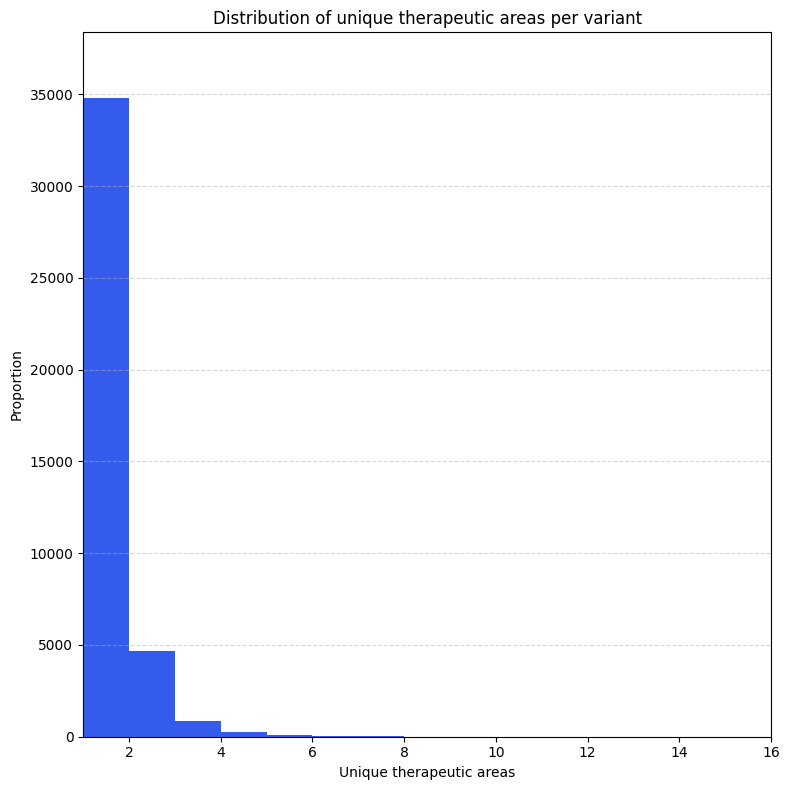

In [ ]:
plt.figure(figsize=(8, 8))
n, bins, patches = plt.hist(
    variant_pd["uniqueTherapeuticAreas"],
    bins=range(
        int(variant_pd["uniqueTherapeuticAreas"].min()),
        int(variant_pd["uniqueTherapeuticAreas"].max()) + 2,
    ),
    color="#345BEB",
)
plt.title("Distribution of unique therapeutic areas per variant")
plt.xlabel("Unique therapeutic areas")
plt.ylabel("Proportion")
plt.gca().set_ylim(0, plt.gca().get_ylim()[1] * 1.05)
plt.gca().set_xlim(bins[0], bins[-1])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


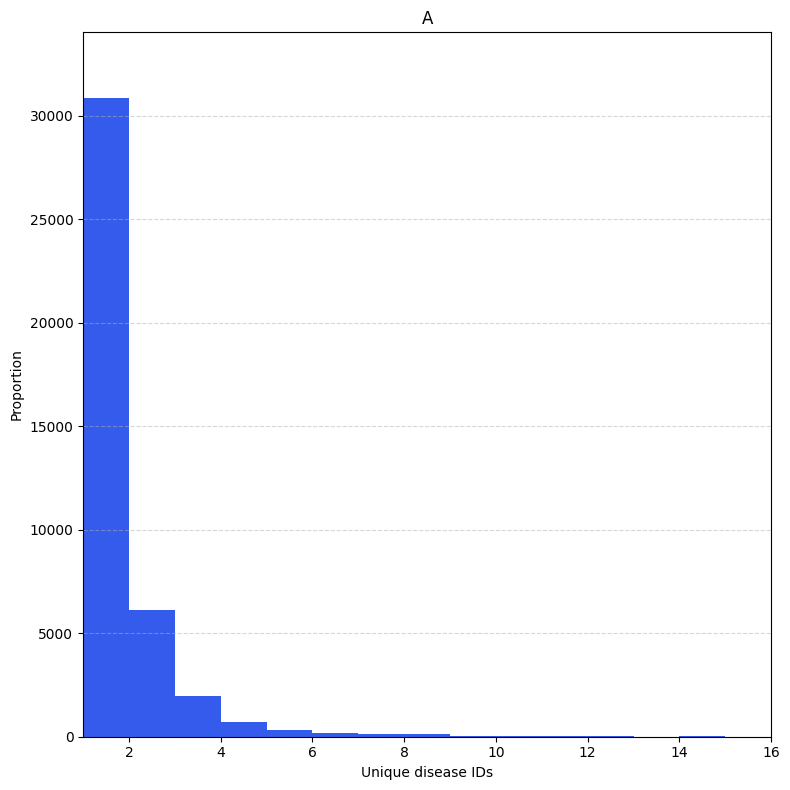

In [ ]:
plt.figure(figsize=(8, 8))
data = variant_pd[variant_pd["uniqueDiseases"] <= 15]["uniqueDiseases"]
bins = range(int(data.min()), int(data.max()) + 2)
n, bins, patches = plt.hist(
    data,
    bins=bins,
    color="#345BEB",
)
plt.title("A")
plt.xlabel("Unique disease IDs")
plt.ylabel("Proportion")
plt.gca().set_ylim(0, plt.gca().get_ylim()[1] * 1.05)
plt.gca().set_xlim(bins[0], bins[-1])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
print("Number with more than one:", len(variant_pd[variant_pd["uniqueDiseases"] > 1]))
print(
    "Percentage with more than 1:",
    len(variant_pd[variant_pd["uniqueDiseases"] > 1]) / len(variant_pd),
)
print("Mean:", variant_pd["uniqueDiseases"].mean())
print("Median:", variant_pd["uniqueDiseases"].median())
print("Max:", variant_pd["uniqueDiseases"].max())
print("Standard Deviation:", variant_pd["uniqueDiseases"].std())


Number with more than one: 9828
Percentage with more than 1: 0.24143860855893481
Mean: 1.4796098855205622
Median: 1.0
Max: 85
Standard Deviation: 1.5444252603214184


# Unique Therapeutic Areas


Univariate regression results:
                     covariate  coefficient  std_error       p_value
0                   maxAbsBeta     0.063283   0.003904  4.358868e-59
1  maxCoefficientDetermination     0.039349   0.002822  3.460952e-44
2                       maxMAF     0.017104   0.004542  1.662870e-04
3       maxEffectiveSampleSize     0.070287   0.004667  2.974352e-51
4        yearsSincePublication     0.073705   0.004238  9.344674e-68
5               gerpNormalised     0.020167   0.004482  6.822045e-06
6                    vepBinary     0.045973   0.003944  2.163465e-31
Multiple regression results:
                     covariate  coefficient  std_error        p_value
0                   maxAbsBeta     0.101224   0.005286   9.581443e-82
1  maxCoefficientDetermination     0.004560   0.004023   2.569921e-01
2                       maxMAF     0.041822   0.004964   3.595053e-17
3       maxEffectiveSampleSize     0.135250   0.005056  1.262278e-157
4        yearsSincePublication     0.0

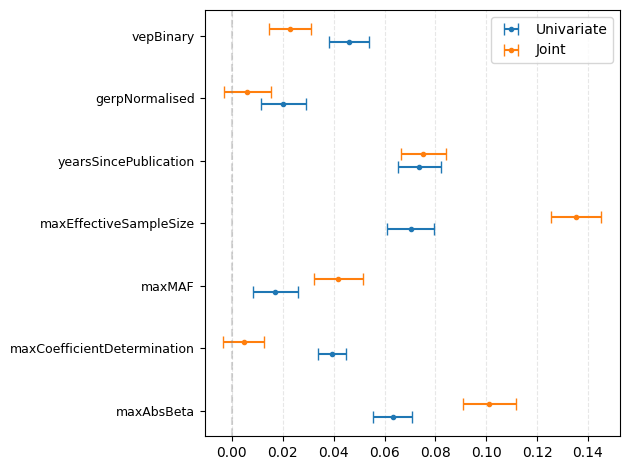

In [17]:
df = variant_pd[
    [
        "uniqueTherapeuticAreas",
        "maxAbsBeta",
        "maxCoefficientDetermination",
        "maxMAF",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "gerpNormalised",
        "vepScore",
    ]
].copy()
df["gerpNormalised"] = df["gerpNormalised"].fillna(df["gerpNormalised"].mean())
df["vepBinary"] = (df["vepScore"] >= 0.66).astype(int)
df["yearsSincePublication"] = (
    2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year
)
df["yearsSincePublication"] = df["yearsSincePublication"].fillna(
    df["yearsSincePublication"].mean()
)

# Standardize covariates
for col in [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
    "maxEffectiveSampleSize",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        df[col] = (df[col] - df[col].mean()) / df[col].std()


covariates_univariate = [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
]
covariates_multi = [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueTherapeuticAreas"]
    model_uni = sm.Poisson(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueTherapeuticAreas"]
model_multi = sm.Poisson(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2


0.13830407989979301

In [ ]:
multi_df.to_clipboard(index=False, sep="\t")


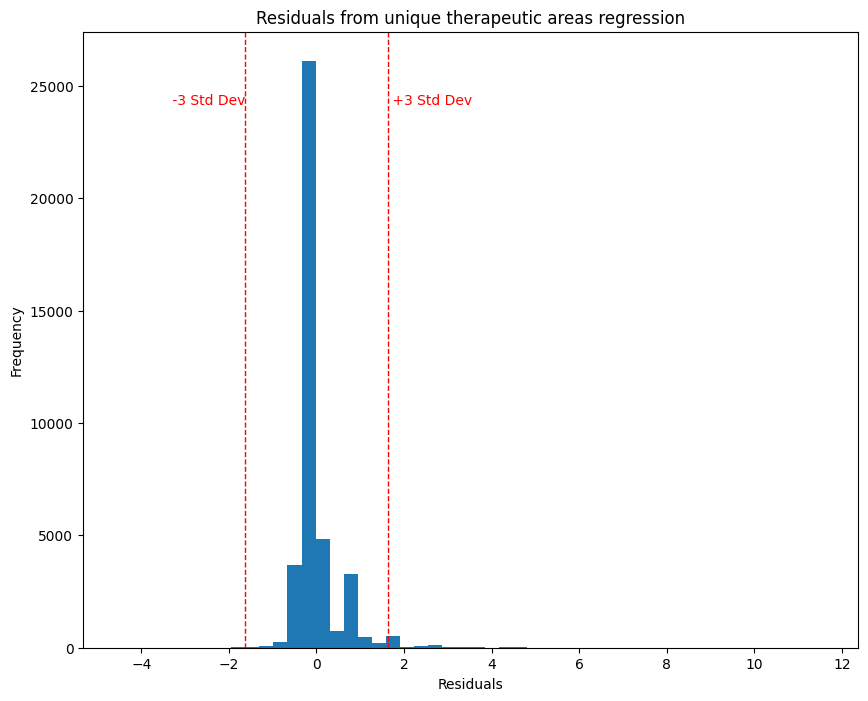

In [ ]:
residuals_multi = model_multi.resid_response
std_dev_residuals = np.std(residuals_multi)

plt.figure(figsize=(10, 8))
plt.hist(residuals_multi, bins=50)
plt.title("Residuals from unique therapeutic areas regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Add vertical lines for standard deviations
plt.axvline(float(3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)
plt.axvline(float(-3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)

# Add text annotations for the lines
y_lim = plt.ylim()
plt.text(
    float(3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " +3 Std Dev",
    color="r",
    verticalalignment="top",
)
plt.text(
    float(-3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " -3 Std Dev",
    color="r",
    horizontalalignment="right",
    verticalalignment="top",
)

plt.show()


In [21]:
outliers_below = variant_pd[residuals_multi < -3 * std_dev_residuals]
outliers_above = variant_pd[residuals_multi > 3 * std_dev_residuals]
outliers_below.to_csv(
    "/users/dc16/output/gentropy_paper/therapy_areas_outliers_below.csv", header=True
)
outliers_above.to_csv(
    "/users/dc16/output/gentropy_paper/therapy_areas_outliers_above.csv", header=True
)


# Unique Diseases full model


Univariate regression results:
                     covariate  coefficient  std_error        p_value
0                   maxAbsBeta     0.145346   0.003156   0.000000e+00
1  maxCoefficientDetermination     0.097125   0.003029  1.475793e-225
2                       maxMAF     0.019687   0.004274   4.098300e-06
3       maxEffectiveSampleSize     0.146594   0.004497  4.388041e-233
4        yearsSincePublication     0.184366   0.003648   0.000000e+00
5               gerpNormalised     0.053024   0.004140   1.465634e-37
6                    vepBinary     0.095145   0.003303  2.038712e-182
Multiple regression results:
                     covariate  coefficient  std_error       p_value
0                   maxAbsBeta     0.190277   0.004031  0.000000e+00
1  maxCoefficientDetermination    -0.001076   0.003034  7.228780e-01
2                       maxMAF     0.068259   0.004520  1.585057e-51
3       maxEffectiveSampleSize     0.271089   0.004510  0.000000e+00
4        yearsSincePublication     

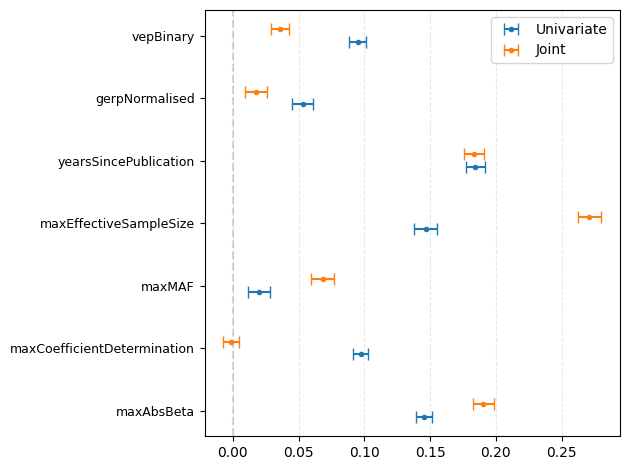

In [22]:
df = variant_pd[
    [
        "uniqueDiseases",
        "maxAbsBeta",
        "maxCoefficientDetermination",
        "maxMAF",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "gerpNormalised",
        "vepScore",
    ]
].copy()
df["gerpNormalised"] = df["gerpNormalised"].fillna(df["gerpNormalised"].mean())
df["vepBinary"] = (df["vepScore"] >= 0.66).astype(int)
df["yearsSincePublication"] = (
    2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year
)
df["yearsSincePublication"] = df["yearsSincePublication"].fillna(
    df["yearsSincePublication"].mean()
)

# Standardize covariates
for col in [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
    "maxEffectiveSampleSize",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        if df[col].std() > 0:
            df[col] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[col] = 0


covariates_univariate = [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
]
covariates_multi = [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2


0.2175838782077978

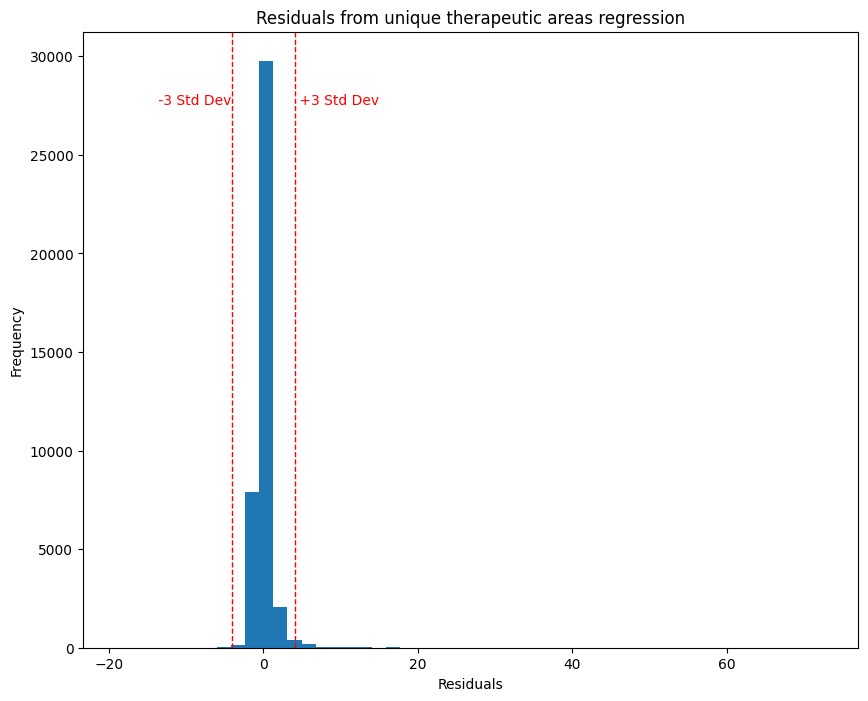

In [ ]:
residuals_multi = model_multi.resid_response
std_dev_residuals = np.std(residuals_multi)

plt.figure(figsize=(10, 8))
plt.hist(residuals_multi, bins=50)
plt.title("Residuals from unique therapeutic areas regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Add vertical lines for standard deviations
plt.axvline(float(3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)
plt.axvline(float(-3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)

# Add text annotations for the lines
y_lim = plt.ylim()
plt.text(
    float(3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " +3 Std Dev",
    color="r",
    verticalalignment="top",
)
plt.text(
    float(-3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " -3 Std Dev",
    color="r",
    horizontalalignment="right",
    verticalalignment="top",
)

plt.show()


In [ ]:
outliers_below = variant_pd[residuals_multi < -3 * std_dev_residuals]
outliers_above = variant_pd[residuals_multi > 3 * std_dev_residuals]
outliers_below.to_csv(
    "/users/dc16/output/gentropy_paper/diseases_outliers_below.csv", header=True
)
outliers_above.to_csv(
    "/users/dc16/output/gentropy_paper/diseases_outliers_above.csv", header=True
)


In [ ]:
variant_pd_with_resid = variant_pd.copy()
variant_pd_with_resid["fullModelDiseasesResid"] = model_multi.resid_response


# Unique diseases biological factors


Univariate regression results:
        covariate  coefficient  std_error        p_value
0      maxAbsBeta     0.145346   0.003156   0.000000e+00
1          maxMAF     0.019687   0.004274   4.098300e-06
2  gerpNormalised     0.053024   0.004140   1.465634e-37
3       vepBinary     0.095145   0.003303  2.038712e-182
Multiple regression results:
        covariate  coefficient  std_error       p_value
0      maxAbsBeta     0.154064   0.003403  0.000000e+00
1          maxMAF     0.094272   0.004465  5.724711e-99
2  gerpNormalised     0.024435   0.004279  1.128213e-08
3       vepBinary     0.065468   0.003555  1.003750e-75
Pseudo R-squared: 0.022192529856626897


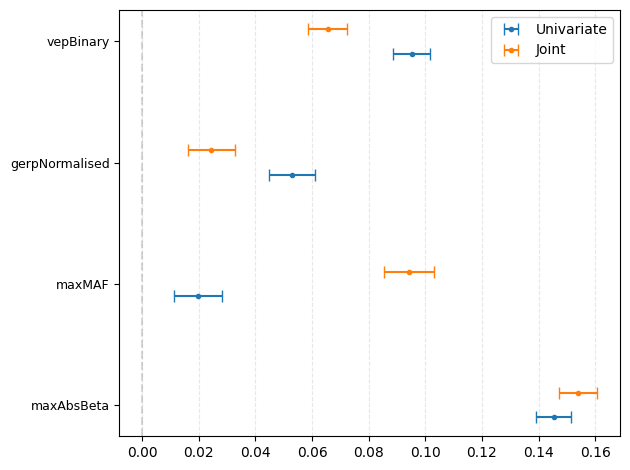

In [ ]:
df = variant_pd[
    [
        "uniqueDiseases",
        "maxAbsBeta",
        "maxMAF",
        "gerpNormalised",
        "vepScore",
    ]
].copy()
df["gerpNormalised"] = df["gerpNormalised"].fillna(df["gerpNormalised"].mean())
df["vepBinary"] = (df["vepScore"] >= 0.66).astype(int)

# Standardize covariates
for col in [
    "maxAbsBeta",
    "maxMAF",
    "gerpNormalised",
    "vepBinary",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        if df[col].std() > 0:
            df[col] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[col] = 0


covariates_univariate = [
    "maxAbsBeta",
    "maxMAF",
    "gerpNormalised",
    "vepBinary",
]
covariates_multi = [
    "maxAbsBeta",
    "maxMAF",
    "gerpNormalised",
    "vepBinary",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2


0.055072494164970724

In [ ]:
variant_pd_with_resid["biologicalFactorsDiseasesResid"] = model_multi.resid_response


# Unique diseases statistical factors


Univariate regression results:
                     covariate  coefficient  std_error        p_value
0  maxCoefficientDetermination     0.097125   0.003029  1.475793e-225
1       maxEffectiveSampleSize     0.146594   0.004497  4.388041e-233
2        yearsSincePublication     0.184366   0.003648   0.000000e+00
Multiple regression results:
                     covariate  coefficient  std_error        p_value
0  maxCoefficientDetermination     0.087350   0.003175  1.413835e-166
1       maxEffectiveSampleSize     0.228084   0.004492   0.000000e+00
2        yearsSincePublication     0.205590   0.003909   0.000000e+00
Pseudo R-squared: 0.04555790457704001


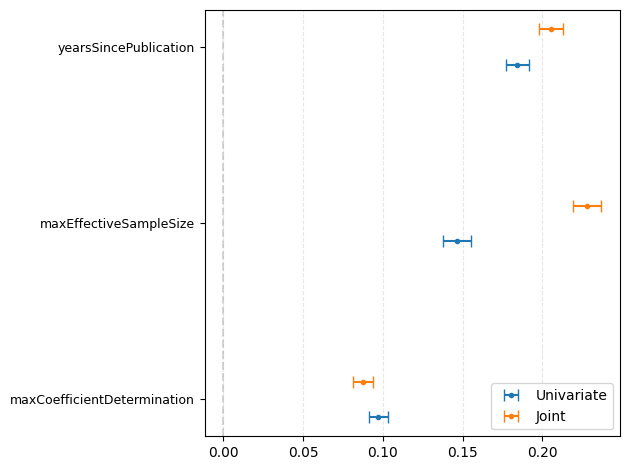

In [ ]:
df = variant_pd[
    [
        "uniqueDiseases",
        "maxCoefficientDetermination",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
    ]
].copy()
df["yearsSincePublication"] = (
    2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year
)
df["yearsSincePublication"] = df["yearsSincePublication"].fillna(
    df["yearsSincePublication"].mean()
)

# Standardize covariates
for col in [
    "maxCoefficientDetermination",
    "yearsSincePublication",
    "maxEffectiveSampleSize",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        if df[col].std() > 0:
            df[col] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[col] = 0


covariates_univariate = [
    "maxCoefficientDetermination",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
]
covariates_multi = [
    "maxCoefficientDetermination",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2


0.007366749058321124

In [ ]:
variant_pd_with_resid["statisticalFactorsDiseasesResid"] = model_multi.resid_response


In [ ]:
variant_pd_with_resid.to_csv(
    "/users/dc16/output/gentropy_paper/variants_with_residuals.csv", index=False
)


In [ ]:
variant_pleiotropy.sort(f.desc("uniqueDiseases")).show()


+----------------+-------------------+--------------------+-------------------+---------------------------+---------------------------+----------------------+----------------------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-----------------------+--------------+----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+--------------------+--------------------------+--------------------+------------+-----------

In [ ]:
pleiotropic_discordant_variants = (
    variant_pleiotropy.filter(f.col("betaSignConcordance") <= 0.8)
    .filter(f.col("uniqueDiseases") >= 10)
    .sort(f.desc("uniqueDiseases"))
)
pleiotropic_discordant_variants.show()


+----------------+------------------+--------------------+-------------------+---------------------------+---------------------------+----------------------+----------------------+--------------------+--------------------+--------------------+--------------------+------------------+-------------------+-----------------------+--------------+----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+--------------------+--------------------------+--------------------+------------+-------------

In [ ]:
(
    pleiotropic_discordant_variants.select(
        "variantId",
        "betaSignConcordance",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "uniqueDiseaseNames",
        "uniqueTherapeuticAreaNames",
        "prioritisedGenes",
    ).write.parquet(
        "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/pleiotropic_discordant_variants",
        mode="overwrite",
    )
)


In [ ]:
(
    session.spark.read.parquet(
        "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/pleiotropic_discordant_variants"
    ).show()
)


+----------------+-------------------+--------------+----------------------+--------------------+--------------------------+--------------------+
|       variantId|betaSignConcordance|uniqueDiseases|uniqueTherapeuticAreas|  uniqueDiseaseNames|uniqueTherapeuticAreaNames|    prioritisedGenes|
+----------------+-------------------+--------------+----------------------+--------------------+--------------------------+--------------------+
| 19_44908684_T_C| 0.6594594594594595|            85|                    15|[MONDO_0021187, E...|      [OTAR_0000020, EF...|   [ENSG00000130203]|
|  2_27508073_T_C| 0.7021276595744681|            34|                    13|[EFO_0004274, MON...|      [OTAR_0000006, EF...|   [ENSG00000084734]|
| 22_28725099_A_G| 0.6944444444444444|            32|                     4|[EFO_0003869, MON...|      [MONDO_0045024, o...|   [ENSG00000183765]|
| 1_169549811_C_T|                0.8|            30|                     9|[HP_0001891, HP_0...|      [other, EFO_00037...|

In [ ]:
# Create a dataframe with disease and therapeutic area information
disease_df = session.spark.read.parquet(
    "gs://open-targets-data-releases/25.06/output/disease/disease.parquet"
).select(f.col("id"), f.col("name"))

# Create a mapping from diseaseId to diseaseName
disease_id_to_name = (
    studies.withColumn("exploded_disease_id", f.explode("diseaseIds"))
    .join(
        disease_df.alias("d"),
        f.col("exploded_disease_id") == f.col("d.id"),
        "left",
    )
    .groupBy("studyId")
    .agg(f.collect_list("name").alias("diseaseNames"))
)

# Create a mapping from therapeuticAreaId to therapeuticAreaName
ta_id_to_name = (
    studies.withColumn("exploded_ta_id", f.explode("mappedTherapeuticAreas"))
    .join(
        disease_df.alias("t"),
        f.col("exploded_ta_id") == f.col("t.id"),
        "left",
    )
    .withColumn(
        "ta_name",
        f.when(f.col("exploded_ta_id") == "other", f.lit("other")).otherwise(
            f.col("t.name")
        ),
    )
    .groupBy("studyId")
    .agg(f.collect_list("ta_name").alias("therapeuticAreaNames"))
)

# Join the new columns back to the studies dataframe
studies_with_names = studies.join(disease_id_to_name, "studyId", "left").join(
    ta_id_to_name, "studyId", "left"
)

# Show the result
studies_with_names.select(
    "studyId",
    "diseaseIds",
    "diseaseNames",
    "mappedTherapeuticAreas",
    "therapeuticAreaNames",
).show(truncate=False)


+--------------------------------------+---------------------------------------+---------------------------------------------------------------+----------------------------------+--------------------------------------------------------------------+
|studyId                               |diseaseIds                             |diseaseNames                                                   |mappedTherapeuticAreas            |therapeuticAreaNames                                                |
+--------------------------------------+---------------------------------------+---------------------------------------------------------------+----------------------------------+--------------------------------------------------------------------+
|FINNGEN_R12_AUTOIMMUNE_HYPERTHYROIDISM|[EFO_0004237]                          |[Graves disease]                                               |[EFO_0000540]                     |[immune system disease]                                             |
|FIN

In [ ]:
df_for_plot = (
    qualified_cs.join(
        studies_with_names.select(
            "studyId",
            "diseaseIds",
            "diseaseNames",
            "mappedTherapeuticAreas",
            "therapeuticAreaNames",
        ),
        "studyId",
        "left",
    )
    .filter(f.col("variantId") == "19_44908684_T_C")
    .filter(f.col("originalBeta").isNotNull())
    .select(
        "studyId",
        "diseaseIds",
        "diseaseNames",
        "mappedTherapeuticAreas",
        "therapeuticAreaNames",
        "rescaledStatistics.zScore",
        "rescaledStatistics.estimatedBeta",
        "rescaledStatistics.estimatedSE",
        "variantStatistics.pValueMantissa",
        "variantStatistics.pValueExponent",
    )
    .sort("pValueExponent")
    .show()
)


+--------------------+---------------+--------------------+----------------------+--------------------+------------------+-------------------+--------------------+--------------+--------------+
|             studyId|     diseaseIds|        diseaseNames|mappedTherapeuticAreas|therapeuticAreaNames|            zScore|      estimatedBeta|         estimatedSE|pValueMantissa|pValueExponent|
+--------------------+---------------+--------------------+----------------------+--------------------+------------------+-------------------+--------------------+--------------+--------------+
|        GCST90480731|[MONDO_0004975]| [Alzheimer disease]|         [EFO_0000618]|[nervous system d...| 38.45960218202991| 0.9899354319983619|0.025739617048376674|           1.0|          -323|
|FINNGEN_R12_KRA_P...|   [HP_0000726]|          [Dementia]|               [other]|             [other]| 37.53138248632944|0.47663034843493174|0.012699514828917938|         2.225|          -308|
|FINNGEN_R12_AD_LO...|  [EFO_1

/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_36472/1518045112.py:38: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_36472/1518045112.py:38: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



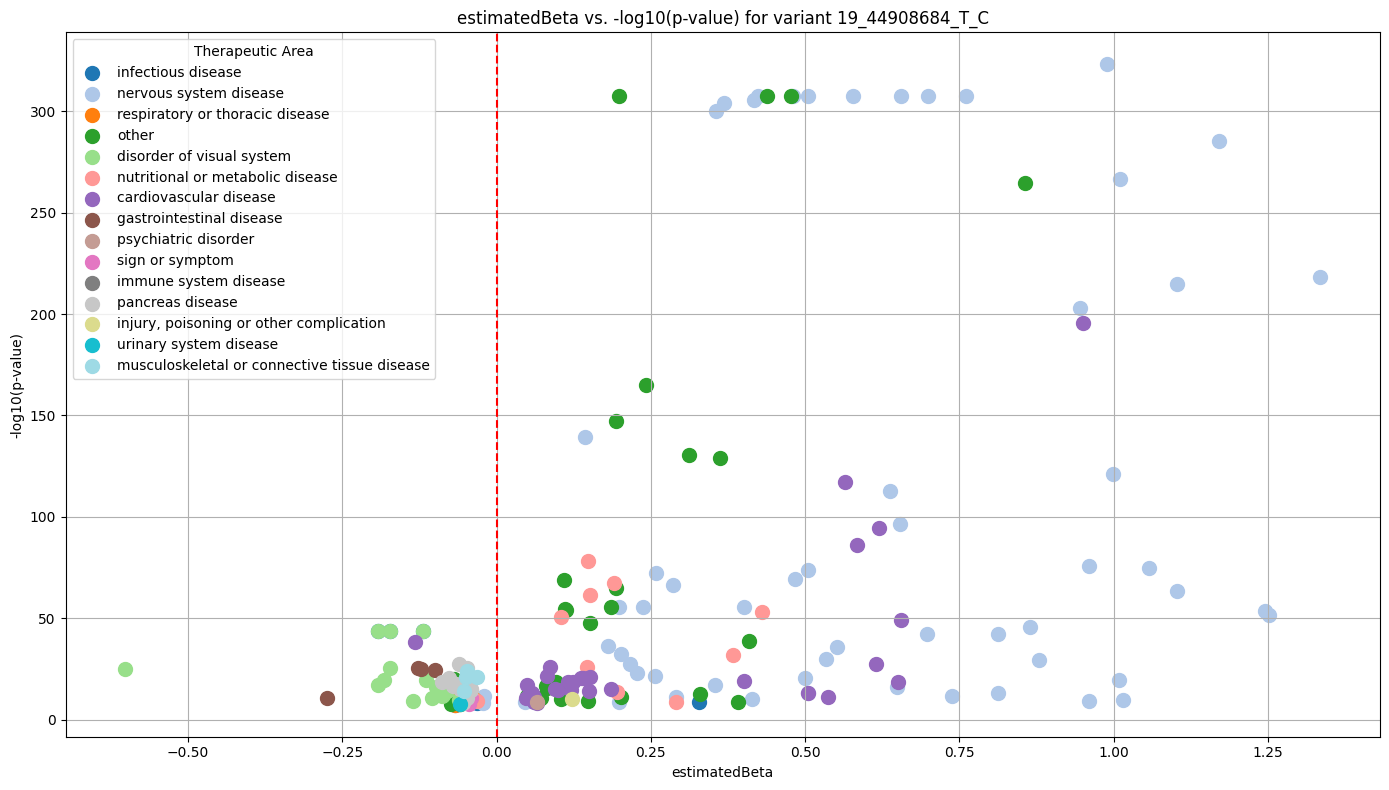

25/11/21 19:21:57 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1082164 ms exceeds timeout 120000 ms
25/11/21 19:21:57 WARN SparkContext: Killing executors is not supported by current scheduler.
25/11/21 19:32:02 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

In [ ]:
df_for_plot = (
    qualified_cs.filter(f.col("variantId") == "19_44908684_T_C")
    .filter(f.col("originalBeta").isNotNull())
    .join(
        studies_with_names.select(
            "studyId",
            "diseaseIds",
            "diseaseNames",
            "mappedTherapeuticAreas",
            "therapeuticAreaNames",
        ),
        "studyId",
        "left",
    )
    .select(
        "studyId",
        "diseaseIds",
        "diseaseNames",
        "mappedTherapeuticAreas",
        "therapeuticAreaNames",
        "rescaledStatistics.estimatedBeta",
        "variantStatistics.pValueMantissa",
        "variantStatistics.pValueExponent",
    )
    .toPandas()
)

df_for_plot["neg_log10_p"] = -(
    np.log10(df_for_plot["pValueMantissa"]) + df_for_plot["pValueExponent"]
)

# Explode the mappedTherapeuticAreas column to have one row per therapeutic area
df_for_plot_exploded = df_for_plot.explode("therapeuticAreaNames")

# Create a color map for therapeutic areas
unique_tas = df_for_plot_exploded["therapeuticAreaNames"].unique()
# Using a colormap with enough distinct colors
colors = plt.cm.get_cmap("tab20", len(unique_tas))
ta_color_map = {ta: colors(i) for i, ta in enumerate(unique_tas)}

plt.figure(figsize=(14, 8))

# Plot each therapeutic area with a different color
for ta, color in ta_color_map.items():
    subset = df_for_plot_exploded[df_for_plot_exploded["therapeuticAreaNames"] == ta]
    plt.scatter(
        subset["estimatedBeta"], subset["neg_log10_p"], label=ta, color=color, s=100
    )

plt.xlabel("estimatedBeta")
plt.ylabel("-log10(p-value)")
plt.title("estimatedBeta vs. -log10(p-value) for variant 19_44908684_T_C")
plt.axvline(0, color="red", linestyle="--")
plt.grid(True)
plt.legend(title="Therapeutic Area", loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# Group by therapeutic area and calculate beta sign concordance
def beta_concordance_and_sign(betas):
    """Calculates the proportion of the most frequent sign and the sign itself."""
    positive_betas = (betas > 0).sum()
    negative_betas = (betas < 0).sum()
    total_betas = positive_betas + negative_betas

    if total_betas == 0:
        concordance = np.nan
        sign = "N/A"
    else:
        concordance = max(positive_betas, negative_betas) / total_betas
        if positive_betas > negative_betas:
            sign = "+"
        elif negative_betas > positive_betas:
            sign = "-"
        else:
            sign = "Equal"

    return pd.Series({"concordance": concordance, "dominant_sign": sign})


# Apply the function to each therapeutic area group
beta_concordance_by_ta = (
    df_for_plot_exploded.groupby("therapeuticAreaNames")
    .apply(
        lambda g: pd.Series(
            {
                **beta_concordance_and_sign(g["estimatedBeta"]),
                "unique_studyIds": g["studyId"].nunique(),
            }
        )
    )
    .reset_index()
)


print("Beta sign concordance by therapeutic area:")
beta_concordance_by_ta


Beta sign concordance by therapeutic area:


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_36472/4108732765.py:26: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,therapeuticAreaNames,concordance,dominant_sign,unique_studyIds
0,cardiovascular disease,0.933333,+,30
1,disorder of visual system,1.000000,-,16
2,gastrointestinal disease,1.000000,-,6
3,immune system disease,1.000000,-,1
4,infectious disease,0.888889,-,9
5,"injury, poisoning or other complication",1.000000,+,1
6,musculoskeletal or connective tissue disease,1.000000,-,4
7,nervous system disease,0.933333,+,60
8,nutritional or metabolic disease,0.818182,+,11
9,other,0.843750,+,32


In [ ]:
beta_concordance_by_ta.to_clipboard(index=False, sep="\t")


In [ ]:
top_1_positive_per_group = (
    df_for_plot_exploded[df_for_plot_exploded["estimatedBeta"] > 0]
    .groupby("therapeuticAreaNames")
    .apply(lambda x: x.nlargest(1, "estimatedBeta"))
    .reset_index(drop=True)
    .sort_values(by="estimatedBeta", ascending=False)
)

top_1_positive_per_group


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_36472/814183356.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,studyId,diseaseIds,diseaseNames,mappedTherapeuticAreas,therapeuticAreaNames,estimatedBeta,pValueMantissa,pValueExponent,neg_log10_p
3,FINNGEN_R12_AD_EO_EXMORE,[MONDO_0004975],[Alzheimer disease],[EFO_0000618],nervous system disease,1.335100,5.164000,-219,218.287014
0,GCST90449025,[EFO_0004718],[vascular dementia],[EFO_0000319],cardiovascular disease,0.950964,3.000000,-196,195.522879
5,FINNGEN_R12_F5_DEMNAS,[HP_0000726],[Dementia],[other],other,0.855802,3.776000,-265,264.422968
4,GCST90104007,[MONDO_0001336],[familial hyperlipidemia],[OTAR_0000020],nutritional or metabolic disease,0.429422,4.907381,-54,53.309150
1,FINNGEN_R12_I9_PROGVASC,[EFO_0007455],[progressive multifocal leukoencephalopathy],[EFO_0005741],infectious disease,0.327585,1.612000,-9,8.792635
2,GCST90161240,[EFO_0003964],[hip fracture],[OTAR_0000009],"injury, poisoning or other complication",0.122789,3.764422,-11,10.424302
6,FINNGEN_R12_KRA_PSY_SUBSTANCE_EXMORE,[MONDO_0002491],[substance abuse],[MONDO_0002025],psychiatric disorder,0.064930,1.106000,-9,8.956245


In [ ]:
top_1_positive_per_group.to_csv(
    "/users/dc16/output/gentropy_paper/top_1_positive_per_ta.csv",
    index=False,
    header=True,
)


In [45]:
top_1_negative_per_group = (
    df_for_plot_exploded[df_for_plot_exploded["estimatedBeta"] < 0]
    .groupby("therapeuticAreaNames")
    .apply(lambda x: x.nsmallest(1, "estimatedBeta"))
    .reset_index(drop=True)
    .sort_values(by="estimatedBeta", ascending=True)
)
top_1_negative_per_group


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_36472/2214753718.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,studyId,diseaseIds,diseaseNames,mappedTherapeuticAreas,therapeuticAreaNames,estimatedBeta,pValueMantissa,pValueExponent,neg_log10_p
1,GCST90448094,[EFO_0001365],[age-related macular degeneration],[MONDO_0024458],disorder of visual system,-0.601686,9.000000,-26,25.045757
2,GCST90275047,[EFO_0003095],[non-alcoholic fatty liver disease],[EFO_0010282],gastrointestinal disease,-0.275130,1.102189,-11,10.957744
4,GCST90250832,"[MONDO_0100096, EFO_0001365]","[COVID-19, age-related macular degeneration]","[MONDO_0024458, EFO_0005741]",infectious disease,-0.191745,1.000000,-44,44.000000
0,GCST90432152,[EFO_0004214],[Abdominal Aortic Aneurysm],[EFO_0000319],cardiovascular disease,-0.132783,5.000000,-39,38.301030
9,GCST90475492,[EFO_0000400],[diabetes mellitus],[EFO_0009605],pancreas disease,-0.089233,2.000000,-19,18.698970
8,FINNGEN_R12_J10_BRONCHITIS,[HP_0012388],[Acute bronchitis],[other],other,-0.073423,8.084000,-9,8.092374
10,FINNGEN_R12_ASTHMA_ACUTE_RESPIRATORY_INFECTIONS,"[MONDO_0004979, MONDO_0024355]","[asthma, respiratory tract infectious disorder]","[EFO_0005741, OTAR_0000010]",respiratory or thoracic disease,-0.067548,3.117000,-8,7.506263
12,GCST90479881,[EFO_0004997],[type 2 diabetes nephropathy],[EFO_0009690],urinary system disease,-0.059317,8.714203,-9,8.059772
11,FINNGEN_R12_RX_CODEINE_TRAMADOL,"[GO_0009410, EFO_0003843]","[response to xenobiotic stimulus, pain]","[other, EFO_0003765]",sign or symptom,-0.056165,1.274000,-16,15.894831
7,GCST90475759,"[EFO_0001073, MONDO_0003916]","[obesity, overnutrition]",[OTAR_0000020],nutritional or metabolic disease,-0.052172,5.000000,-17,16.301030


In [ ]:
top_1_negative_per_group.to_csv(
    "/users/dc16/output/gentropy_paper/top_1_negative_per_ta.csv",
    index=False,
    header=True,
)
